# Deep Learning Project - Classifier

Group 4 formed by:
- Daniel Carneiro (up202108832)
- David Pinto (up201704300)
- José Santos (up202108729)

This assignment is separated into two parts.

- Classifier Model
- Generative Model

The dataset to be used is the DeepFakeFace dataset obtained through [huggingface](https://huggingface.co/datasets/OpenRL/DeepFakeFace).

We devide the Classifier Notebook in two notebooks (Creation Model, Model Comparison), this Notebook we will focus on its creation. 

## Imports and Global Setup

In [2]:
import warnings
warnings.filterwarnings("ignore")
from tqdm import tqdm
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from datasets import load_from_disk, load_dataset
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision import models


class CNNModel_dropout(nn.Module):
    def __init__(self,num_classes=2, droprate=0.1,epsilon=0.001):
        super(CNNModel_dropout, self).__init__()

        # First convolutional layer: 3 input channels (RGB), 32 filters, 3x3 kernel, padding=1 to maintain spatial size
        
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32, eps=epsilon)

        # Second convolutional layer: 32 input channels, 64 filters
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64, eps=epsilon)

        # Third convolutional layer: 64 input channels, 128 filters
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128, eps=epsilon)

        # Fourth convolutional layer: 128 input channels, 256 filters
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256, eps=epsilon)

        # Fifth convolutional layer: 256 input channels, 512 filters
        self.conv5 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(512, eps=epsilon)
        
        # Max pooling layer: reduces spatial dimensions by half
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Dropout layer to prevent overfitting
        self.drop = nn.Dropout(droprate)
        
        # Global Average Pooling: reduces feature maps to 1x1, turning each channel into a single value
        self.global_avg_pool = nn.AdaptiveAvgPool2d(1)

        # Fully connected layer (Dense layer): Maps 512 features to 'num_classes' outputs
        self.fc = nn.Linear(512, num_classes)
        
    def forward(self, x):
        # First convolution -> BatchNorm -> ReLU -> Max Pooling
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        
        # Second convolution -> BatchNorm -> ReLU -> Max Pooling
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.drop(x) # Apply dropout to prevent overfitting

        # Third convolution -> BatchNorm -> ReLU -> Max Pooling
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.drop(x) # Apply dropout
        
        # Fourth convolution -> BatchNorm -> ReLU -> Max Pooling
        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        x = self.drop(x) # Apply dropout
        
        # Fifth convolution -> BatchNorm -> ReLU -> Max Pooling
        x = self.pool(F.relu(self.bn5(self.conv5(x))))        
        x = self.drop(x) # Apply dropout
        
        # Global Average Pooling: Reduces feature maps to 1x1 per channel
        x = self.global_avg_pool(x)
        
        # Flatten the tensor (from [batch_size, 512, 1, 1] to [batch_size, 512])
        x = torch.flatten(x, 1)
        
        # Fully connected layer to get class scores
        x = self.fc(x)
        
        # Apply softmax activation to get class probabilities
        return F.softmax(x, dim=1)

class CNNModel_simple_Nodropout(nn.Module):
    def __init__(self,num_classes=2, epsilon=0.001):
        super(CNNModel_simple_Nodropout, self).__init__()

        # First convolutional layer: 3 input channels (RGB), 32 filters, 3x3 kernel, padding=1 to maintain spatial size
        
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32, eps=epsilon)

        # Second convolutional layer: 32 input channels, 64 filters
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64, eps=epsilon)

        # Third convolutional layer: 64 input channels, 128 filters
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128, eps=epsilon)
        
        # Max pooling layer: reduces spatial dimensions by half
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        
        # Global Average Pooling: reduces feature maps to 1x1, turning each channel into a single value
        self.global_avg_pool = nn.AdaptiveAvgPool2d(1)

        # Fully connected layer (Dense layer): Maps 512 features to 'num_classes' outputs
        self.fc = nn.Linear(128, num_classes)
        
    def forward(self, x):
        # First convolution -> BatchNorm -> ReLU -> Max Pooling
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        
        # Second convolution -> BatchNorm -> ReLU -> Max Pooling
        x = self.pool(F.relu(self.bn2(self.conv2(x))))

        # Third convolution -> BatchNorm -> ReLU -> Max Pooling
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        
        # Global Average Pooling: Reduces feature maps to 1x1 per channel
        x = self.global_avg_pool(x)
        
        # Flatten the tensor (from [batch_size, 512, 1, 1] to [batch_size, 512])
        x = torch.flatten(x, 1)
        
        # Fully connected layer to get class scores
        x = self.fc(x)
        
        # Apply softmax activation to get class probabilities
        return F.softmax(x, dim=1)


# Custom Dataset class
class DeepFakeDataset(Dataset):
    def __init__(self, dataset, transform=None):
        self.dataset = dataset
        self.transform = transform
        self.start_idx = 4  # Ignore the first 4 rows

    def __len__(self):
        return len(self.dataset['train']) - self.start_idx  # Adjust length

    def __getitem__(self, idx):
        idx += self.start_idx  # Shift index to ignore first 4 rows
        image = self.dataset['train'][idx]['image']  # Assuming it's already a PIL.Image
        label = 0 if idx < 90000 else 1  # First 90k are fake, last 30k are real

        if self.transform:
            image = self.transform(image)
        
        return image, torch.tensor(label, dtype=torch.long)
    
def compute_eer(y_true, y_scores):
    """
    Calculate Equal Error Rate (EER)
    :param y_true: True labels (1 for real, 0 for fake)
    :param y_scores: Model scores (probabilities or decision values)
    :return: EER value, threshold where EER occurs
    """
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    fnr = 1 - tpr  # False Negative Rate (FRR)
    
    # Find the threshold where FPR ≈ FNR
    eer_threshold = thresholds[np.nanargmin(np.abs(fpr - fnr))]
    eer = fpr[np.nanargmin(np.abs(fpr - fnr))]
    
    return eer, eer_threshold

def ensure_three_channels(image):
    """
    Convert all images to 3-channel format.
    - If the image is grayscale (1 channel), convert it to RGB (3 channels).
    - If it's already RGB, keep it unchanged.
    """
    if image.mode != "RGB":  # Check if the image is not already RGB
        image = image.convert("RGB")  # Convert grayscale (1 channel) to RGB (3 channels)
    return image

# Define a transformation
transform_normal = transforms.Compose([
    transforms.Lambda(ensure_three_channels),
    transforms.Resize((224, 224)),  # Resize to match CNN input size
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

transform_grayscale = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to match CNN input size
    transforms.Grayscale(num_output_channels=3),  # Convert to 3-channel grayscale
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

transform_contrast = transforms.Compose([
    transforms.Lambda(ensure_three_channels),
    transforms.Resize((224, 224)),  # Resize to match CNN input size
    transforms.ColorJitter(contrast=20), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

transform_saturation = transforms.Compose([
    transforms.Lambda(ensure_three_channels),
    transforms.Resize((224, 224)),  # Resize to match CNN input size
    transforms.ColorJitter(saturation=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

transform_gaussianBlur = transforms.Compose([
    transforms.Lambda(ensure_three_channels),
    transforms.Resize((224, 224)),  # Resize to match CNN input size
    transforms.GaussianBlur(kernel_size=(31,31)),  # Convert to 3-channel grayscale
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

transform_pixelation = transforms.Compose([
    transforms.Lambda(ensure_three_channels),
    transforms.Resize((224//8 , 224//8), interpolation=Image.NEAREST),  # Downscale
    transforms.Resize((224, 224), interpolation=Image.NEAREST), # Resize to match CNN input size
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

def train_model(model,full_dataset,k_folds = 5,num_epochs = 5,lr=0.0001):
    # Move model to GPU if available
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    # Loss function & optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

    all_accuracies = []
    all_aucs = []
    all_eers = []
    
    for fold, (train_idx, test_idx) in enumerate(kf.split(full_dataset)):
        print(f'Fold {fold+1}/{k_folds}')
        
        train_subset = torch.utils.data.Subset(full_dataset, train_idx.tolist())
        test_subset = torch.utils.data.Subset(full_dataset, test_idx.tolist())
        train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
        test_loader = DataLoader(test_subset, batch_size=32, shuffle=False)
        for epoch in range(num_epochs):
            model.train()
            running_loss = 0.0
            with tqdm(total=len(train_loader), desc=f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}") as pbar:
                for images, labels in train_loader:
                    images, labels = images.to(device), labels.to(device)
                    
                    optimizer.zero_grad()
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                    loss.backward()
                    optimizer.step()

                    running_loss += loss.item()
                
                    pbar.set_description(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")
                    pbar.update(1)    
                
            print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")
        
        # Evaluation
        model.eval()
        all_preds, all_labels = [], []
        
        with torch.no_grad():
            with tqdm(total=len(test_loader), desc=f"Evaluating") as pbar:
                for images, labels in test_loader:
                    images, labels = images.to(device), labels.to(device)
                    outputs = model(images)
                    probabilities = torch.softmax(outputs, dim=1)[:, 1]  
                    all_preds.extend(probabilities.cpu().numpy())
                    all_labels.extend(labels.cpu().numpy())
                    pbar.update(1) 

        all_preds = np.array(all_preds)
        all_labels = np.array(all_labels)

        # ---- Compute Metrics ----
        accuracy = accuracy_score(all_labels, all_preds > 0.5)
        auc = roc_auc_score(all_labels, all_preds)
        eer_value, eer_threshold = compute_eer(all_labels, all_preds)

        all_accuracies.append(accuracy)
        all_aucs.append(auc)
        all_eers.append(eer_value)

        print(f"Fold {fold+1} - Accuracy: {accuracy:.4f}, AUC: {auc:.4f}, EER: {eer_value:.4f} (Threshold: {eer_threshold:.4f})")

    print("Training complete.")
    print(f"Average Accuracy: {np.mean(all_accuracies):.4f}")
    print(f"Average AUC: {np.mean(all_aucs):.4f}")
    print(f"Average EER: {np.mean(all_eers):.4f}")
    return model 


In [3]:
save_models_dir = "./models/"
save_dataset_dir = "./dataset/"

## Data Loading & Exploration Data Analysis

In this section, we will load the dataset and perform some basic data exploration and visualization.
The dataset has 120000 images of which:
- Real Images (30000):
    - Wiki (30000)
- Fake Images (90000):
    - Stable Diffusion v1.5 (30000)
    - Stable Diffusion Inpainting (30000)
    - Insight (30000)

In [5]:
try:
    dataset = load_from_disk("./dataset")
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Dataset not found. Trying to download and save him")
    dataset = load_dataset("OpenRL/DeepFakeFace")
    dataset.save_to_disk(save_dataset_dir) 
print(dataset)

Dataset loaded successfully!
DatasetDict({
    train: Dataset({
        features: ['image'],
        num_rows: 120004
    })
})


In [58]:
df_normal = DeepFakeDataset(dataset, transform=transform_normal)
df_grayscale = DeepFakeDataset(dataset, transform=transform_grayscale)
df_contrast = DeepFakeDataset(dataset, transform=transform_contrast)
df_gaussianBlur = DeepFakeDataset(dataset, transform=transform_gaussianBlur)
df_saturation = DeepFakeDataset(dataset, transform=transform_saturation)
df_pixelation = DeepFakeDataset(dataset, transform=transform_pixelation)

As we mentioned before the distribution is extremely unbalanced.

Real: 30000
Fake: 90000



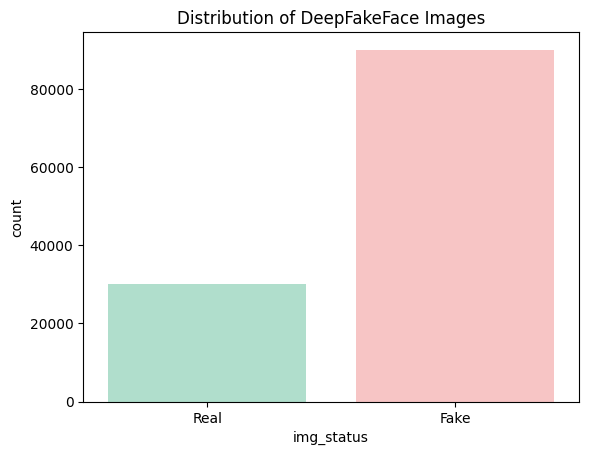

In [59]:
df_aux = pd.DataFrame({'img_status': ['Real'] * 30000 + ['Fake'] * 90000})
real =  30000
fake = 90000

print(f"Real: {real}\nFake: {fake}\n")
sns.countplot(x=df_aux['img_status'],palette=["#A8E6CE", "#FFBDBD"])
plt.xticks([0, 1], ['Real', 'Fake'])
plt.title("Distribution of DeepFakeFace Images")
plt.show()

We can see all the fake and true images using the code below and slide the bar to the number we want, we also can change what df we gonna see changing the df_images in the first line

In [60]:
# change the df here for change the viewer
df_images = df_normal

title_window_fake = 'deep Fake Dataset - Fake Images'
title_window_real = 'deep Fake Dataset - Real Images'

alpha_slider_max = 119999

def tensor_to_cv2_image(tensor):
    """
    Convert a PyTorch tensor (C, H, W) to a format compatible with OpenCV (H, W, C).
    """
    # Ensure tensor is on CPU and convert to NumPy array
    img = tensor.cpu().detach().numpy()

    # If the image was normalized, denormalize it (assuming mean=0.5, std=0.5)
    img = (img * 0.5) + 0.5  # Rescale back to [0, 1] range

    # Convert from (C, H, W) to (H, W, C) for OpenCV
    img = np.transpose(img, (1, 2, 0))

    # Convert from RGB to BGR (OpenCV uses BGR format)
    img = (img * 255).astype(np.uint8)  # Convert to uint8 for display
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    return img

def on_trackbar_fake(val):
    img = tensor_to_cv2_image(df_images[val][0])
    cv2.imshow(title_window_fake, img)

def on_trackbar_real(val):
    img = tensor_to_cv2_image(df_images[val+90000][0])
    cv2.imshow(title_window_real, img)

# Fake images
cv2.namedWindow(title_window_fake)

trackbar_name_fake = 'Fake Photo Index'
cv2.createTrackbar(trackbar_name_fake, title_window_fake , 0, 89999, on_trackbar_fake)

img_fake = tensor_to_cv2_image(df_images[0][0])

cv2.moveWindow(title_window_fake, 50, 0)
cv2.imshow(title_window_fake, img_fake)

# Real images

cv2.namedWindow(title_window_real)

trackbar_name_real = 'Real Photo Index'
cv2.createTrackbar(trackbar_name_real, title_window_real , 0, 29999, on_trackbar_real)

img_real = tensor_to_cv2_image(df_images[90000][0])

cv2.moveWindow(title_window_real, 500, 0)
cv2.imshow(title_window_real, img_real)


cv2.waitKey(0)
cv2.destroyAllWindows()

# Modelling

In this section, we will create the models we will use. We have decided to use a Resnet with a pre-trained model and 2 convolutional neural networks created by us, one with 5 layers and a dropout to avoid overfitting and a simpler one with only 3 layers and without the dropout. Furthermore, all 3 models will be trained with 6 different datasets, to see if any image processing has an effect on the learning.

## Resnet - Normal Images

In [61]:
full_dataset = df_normal
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [62]:
model = models.resnet18(pretrained=True)

# Modify the classifier layer for binary classification
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)  # Binary classification (fake vs real)

model = train_model(model,full_dataset,k_folds = 5,num_epochs = 5,lr=0.0001)

Fold 1/5


Epoch [1/5], Loss: 0.0010:   0%|          | 4/3000 [00:16<3:29:59,  4.21s/it]


KeyboardInterrupt: 

In [ ]:
os.makedirs(save_models_dir, exist_ok=True)
torch.save(model, os.path.join(save_models_dir, "resnet_normal.pth"))

## Resnet - GrayScale Images

In [ ]:
full_dataset = df_grayscale
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
model = models.resnet18(pretrained=True)

# Modify the classifier layer for binary classification
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)  # Binary classification (fake vs real)

model = train_model(model,full_dataset,k_folds = 5,num_epochs = 5,lr=0.0001)

In [ ]:
os.makedirs(save_models_dir, exist_ok=True)
torch.save(model, os.path.join(save_models_dir, "resnet_grayscale.pth"))

## Resnet - Contrast Images

In [ ]:
full_dataset = df_contrast
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
model = models.resnet18(pretrained=True)

# Modify the classifier layer for binary classification
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)  # Binary classification (fake vs real)

model = train_model(model,full_dataset,k_folds = 5,num_epochs = 5,lr=0.0001)

In [ ]:
os.makedirs(save_models_dir, exist_ok=True)
torch.save(model, os.path.join(save_models_dir, "resnet_contrast.pth"))

## Resnet - GaussianBlur Images

In [ ]:
full_dataset = df_gaussianBlur
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
model = models.resnet18(pretrained=True)

# Modify the classifier layer for binary classification
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)  # Binary classification (fake vs real)

model = train_model(model,full_dataset,k_folds = 5,num_epochs = 5,lr=0.0001)

In [ ]:
os.makedirs(save_models_dir, exist_ok=True)
torch.save(model, os.path.join(save_models_dir, "resnet_gaussianblur.pth"))

## Resnet - Saturation Images

In [ ]:
full_dataset = df_saturation
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
model = models.resnet18(pretrained=True)

# Modify the classifier layer for binary classification
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)  # Binary classification (fake vs real)

model = train_model(model,full_dataset,k_folds = 5,num_epochs = 5,lr=0.0001)

In [ ]:
os.makedirs(save_models_dir, exist_ok=True)
torch.save(model, os.path.join(save_models_dir, "resnet_saturation.pth"))

## Resnet - Pixelation Images

In [ ]:
full_dataset = df_pixelation
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
model = models.resnet18(pretrained=True)

# Modify the classifier layer for binary classification
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)  # Binary classification (fake vs real)

model = train_model(model,full_dataset,k_folds = 5,num_epochs = 5,lr=0.0001)

In [ ]:
os.makedirs(save_models_dir, exist_ok=True)
torch.save(model, os.path.join(save_models_dir, "resnet_pixelation.pth"))

## Dropout Model - Normal Images

In [63]:
full_dataset = df_normal
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
model = CNNModel_dropout()

model = train_model(model,full_dataset,k_folds = 5,num_epochs = 5,lr=0.0001)

Fold 1/5


Epoch [1/5], Loss: 0.0008:   0%|          | 4/3000 [00:21<4:33:45,  5.48s/it]


KeyboardInterrupt: 

In [ ]:
os.makedirs(save_models_dir, exist_ok=True)
torch.save(model, os.path.join(save_models_dir, "CNN_dropout_normal.pth"))

## Dropout Model - GrayScale Images

In [65]:
full_dataset = df_grayscale
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
model = CNNModel_dropout()

model = train_model(model,full_dataset,k_folds = 5,num_epochs = 5,lr=0.0001)

Fold 1/5


Epoch [1/5], Loss: 0.0004:   0%|          | 2/3000 [00:07<3:12:43,  3.86s/it]


KeyboardInterrupt: 

In [ ]:
os.makedirs(save_models_dir, exist_ok=True)
torch.save(model, os.path.join(save_models_dir, "CNN_dropout_grayscale.pth"))

## Dropout Model - Contrast Images

In [67]:
full_dataset = df_contrast
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
model = CNNModel_dropout()

model = train_model(model,full_dataset,k_folds = 5,num_epochs = 5,lr=0.0001)

Fold 1/5


Epoch [1/5], Loss: 0.0006:   0%|          | 2/3000 [00:08<3:28:38,  4.18s/it]


KeyboardInterrupt: 

In [69]:
os.makedirs(save_models_dir, exist_ok=True)
torch.save(model, os.path.join(save_models_dir, "CNN_dropout_contrast.pth"))

## Dropout Model - GaussianBlur Images

In [70]:
full_dataset = df_gaussianBlur
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
model = CNNModel_dropout()

model = train_model(model,full_dataset,k_folds = 5,num_epochs = 5,lr=0.0001)

Fold 1/5


Epoch [1/5], Loss: 0.0002:   0%|          | 1/3000 [00:08<7:08:39,  8.58s/it]


KeyboardInterrupt: 

In [73]:
os.makedirs(save_models_dir, exist_ok=True)
torch.save(model, os.path.join(save_models_dir, "CNN_dropout_gaussianblur.pth"))

## Dropout Model - Saturation Images

In [74]:
full_dataset = df_saturation
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
model = CNNModel_dropout()

model = train_model(model,full_dataset,k_folds = 5,num_epochs = 5,lr=0.0001)

Fold 1/5


Epoch [1/5], Loss: 0.0004:   0%|          | 2/3000 [00:08<3:23:15,  4.07s/it]


KeyboardInterrupt: 

In [76]:
os.makedirs(save_models_dir, exist_ok=True)
torch.save(model, os.path.join(save_models_dir, "CNN_dropout_saturation.pth"))

## Dropout Model - Pixelation Images

In [77]:
full_dataset = df_pixelation
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
model = CNNModel_dropout()

model = train_model(model,full_dataset,k_folds = 5,num_epochs = 5,lr=0.0001)

Fold 1/5


Epoch [1/5], Loss: 0.0004:   0%|          | 2/3000 [00:11<4:35:05,  5.51s/it]


KeyboardInterrupt: 

In [80]:
os.makedirs(save_models_dir, exist_ok=True)
torch.save(model, os.path.join(save_models_dir, "CNN_dropout_pixelation.pth"))

## Simple Model - Normal Images

In [81]:
full_dataset = df_normal
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [82]:
model = CNNModel_simple_Nodropout()

model = train_model(model,full_dataset,k_folds = 5,num_epochs = 5,lr=0.0001)

Fold 1/5


Epoch [1/5], Loss: 0.0012:   0%|          | 5/3000 [00:15<2:36:31,  3.14s/it]


KeyboardInterrupt: 

In [83]:
os.makedirs(save_models_dir, exist_ok=True)
torch.save(model, os.path.join(save_models_dir, "CNN_simple_normal.pth"))

## Simple Model - GrayScale Images

In [84]:
full_dataset = df_grayscale
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [85]:
model = CNNModel_simple_Nodropout()

model = train_model(model,full_dataset,k_folds = 5,num_epochs = 5,lr=0.0001)

Fold 1/5


Epoch [1/5], Loss: 0.0005:   0%|          | 2/3000 [00:08<3:29:03,  4.18s/it]


KeyboardInterrupt: 

In [86]:
os.makedirs(save_models_dir, exist_ok=True)
torch.save(model, os.path.join(save_models_dir, "CNN_simple_grayscale.pth"))

## Simple Model - Contrast Images

In [ ]:
full_dataset = df_contrast
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
model = CNNModel_simple_Nodropout()

model = train_model(model,full_dataset,k_folds = 5,num_epochs = 5,lr=0.0001)

In [ ]:
os.makedirs(save_models_dir, exist_ok=True)
torch.save(model, os.path.join(save_models_dir, "CNN_simple_contrast.pth"))

## Simple Model - GaussianBlur Images

In [ ]:
full_dataset = df_gaussianBlur
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
model = CNNModel_simple_Nodropout()

model = train_model(model,full_dataset,k_folds = 5,num_epochs = 5,lr=0.0001)

In [ ]:
os.makedirs(save_models_dir, exist_ok=True)
torch.save(model, os.path.join(save_models_dir, "CNN_simple_gaussianblur.pth"))

## Simple Model - Saturation Images

In [ ]:
full_dataset = df_saturation
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
model = CNNModel_simple_Nodropout()

model = train_model(model,full_dataset,k_folds = 5,num_epochs = 5,lr=0.0001)

In [ ]:
os.makedirs(save_models_dir, exist_ok=True)
torch.save(model, os.path.join(save_models_dir, "CNN_simple_saturation.pth"))

## Simple Model - Pixelation Images

In [ ]:
full_dataset = df_pixelation
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
model = CNNModel_simple_Nodropout()

model = train_model(model,full_dataset,k_folds = 5,num_epochs = 5,lr=0.0001)

In [ ]:
os.makedirs(save_models_dir, exist_ok=True)
torch.save(model, os.path.join(save_models_dir, "CNN_simple_pixelation.pth"))